# Scenario Comparison

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pypsa

# Add the scripts/pypsa-de directory to the path
scripts_path = os.path.join(os.path.dirname(os.getcwd()), 'scripts', 'pypsa-de')
sys.path.append(scripts_path)

from flexibility_utils import tech_colors, scenario_abbrev
from flexibility_plots_scenario_comparison import get_capacities, plot_capacity_comparison, capa_groups

kwargs = {
    "groupby": ["bus", "carrier"],
    "at_port": True,
    "nice_names": False,
}

In [70]:
f = "/home/julian-geis/Documents/06_PhD/02Flexibility/runs/"
run = "20251023-flex-scenario-update" # "20251015-flex-scenario-update-27cl-3h" # "20251013_flex-scenarios-temporal-industry-load-27cl-3h"
scenarios = ["LowFlex50", "LowFlex75", "LowBatt50", "MedFlex", "HigFlex"]
years = [2035, 2045]

In [71]:
networks = {}
for scenario in scenarios:
    for year in years:
        fn = f"{f}/{run}/{scenario}/networks/base_s_27__none_{year}.nc"
        networks[(scenario, year)] = pypsa.Network(fn)

INFO:pypsa.network.io:New version 1.0.2 available! (Current: 0.35.1)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.network.io:New version 1.0.2 available! (Current: 0.35.1)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.network.io:New version 1.0.2 available! (Current: 0.35.1)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.network.io:New version 1.0.2 available! (Current: 0.35.1)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.network.io:New version 1.0.2 available! (Current: 0.35.1)
INFO:pypsa.network.io:Imported network 'Unn

In [72]:
# load variables
results = {}
for scenario in scenarios:
        df = (
        pd.read_excel(
            f"{f}/{run}/{scenario}/ariadne/exported_variables_full.xlsx",
            index_col=list(range(5)),
            # index_col=["Model", "Scenario", "Region", "Variable", "Unit"],
            sheet_name="data",
        )
        .groupby(["Variable", "Unit"], dropna=False)
        .sum()
        ).round(5)
        results[scenario] = df

# Functions

In [73]:
def plot_variable(variable_name, results, scenarios, unit=None):

    fig, ax = plt.subplots(figsize=(6, 4))

    for scenario in scenarios:
        data = results[scenario].loc[variable_name]

        if (unit is None) & (data.index[0] is not None):
            unit = data.index[0]
        elif unit is None:
            unit = "Unspecified unit"

        years = [int(col) for col in data.columns]
        ax.plot(years, data.values[0], marker='*', label=scenario, linewidth=2, markersize=8)
        
        # Set x-axis to show only the years in the data
        if years is not None:
            ax.set_xticks(years)
    
    ax.set_xlabel('Year')
    ax.set_ylabel(unit if unit and pd.notna(unit) else 'Value')
    ax.set_title(variable_name)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



# Start

In [74]:
# filter for vars
search = "Secondary Ener"
vars = results["MedFlex"].index.get_level_values("Variable").unique().to_list()
[v for v in vars if search in v]

['Price|Secondary Energy|Electricity',
 'Price|Secondary Energy|Gases',
 'Price|Secondary Energy|Gases|Biomass',
 'Price|Secondary Energy|Gases|Hydrogen',
 'Price|Secondary Energy|Gases|Natural Gas',
 'Price|Secondary Energy|Hydrogen',
 'Price|Secondary Energy|Hydrogen|Green',
 'Price|Secondary Energy|Liquids',
 'Price|Secondary Energy|Liquids|Hydrogen',
 'Secondary Energy',
 'Secondary Energy Input|Electricity|Heat',
 'Secondary Energy Input|Electricity|Hydrogen',
 'Secondary Energy Input|Electricity|Liquids',
 'Secondary Energy Input|Hydrogen|Electricity',
 'Secondary Energy Input|Hydrogen|Gases',
 'Secondary Energy Input|Hydrogen|Heat',
 'Secondary Energy Input|Hydrogen|Liquids',
 'Secondary Energy|Electricity',
 'Secondary Energy|Electricity|Biomass',
 'Secondary Energy|Electricity|Biomass|Gaseous and Liquid',
 'Secondary Energy|Electricity|Biomass|Solid',
 'Secondary Energy|Electricity|Biomass|w/ CCS',
 'Secondary Energy|Electricity|Biomass|w/o CCS',
 'Secondary Energy|Electricity

## System cost

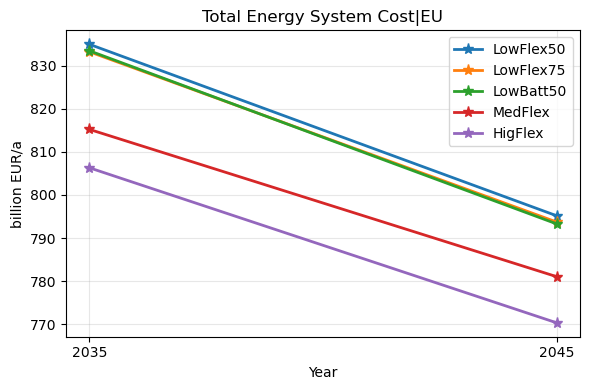

In [75]:
# System costs
# plot_variable("Total Energy System Cost|Trade|Hydrogen", results, scenarios, unit="billion EUR/a")
# plot_variable("Total Energy System Cost|Trade|Electricity", results, scenarios, unit="billion EUR/a")
# plot_variable("Total Energy System Cost", results, scenarios, unit="billion EUR/a")
# plot_variable("Total Energy System Cost|Non Trade", results, scenarios, unit="billion EUR/a")
# plot_variable("Total Energy System Cost|Trade", results, scenarios, unit="billion EUR/a")
plot_variable("Total Energy System Cost|EU", results, scenarios, unit="billion EUR/a")

- system costs increase but not significantly
- import dependency is not clearly higher
- overall trade costs seem to be even lower for NoFlex atm (imports less hydrogen)

# Capacity

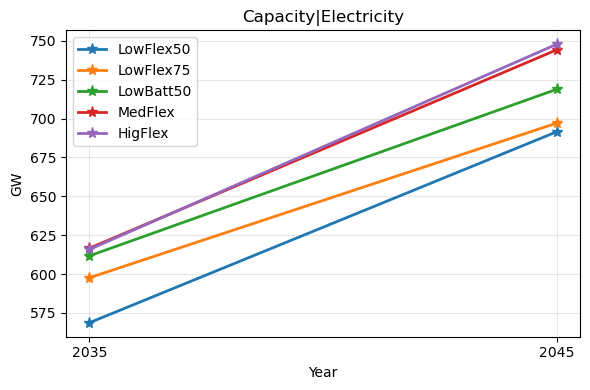

In [76]:
plot_variable("Capacity|Electricity", results, scenarios)
# plot_variable("Capacity|Electricity|Biomass", results, scenarios)
# plot_variable("Capacity|Electricity|Coal", results, scenarios)
# plot_variable("Capacity|Electricity|Gas", results, scenarios)
# plot_variable("Capacity|Electricity|Solar", results, scenarios)
# plot_variable("Capacity|Electricity|Wind", results, scenarios)
# plot_variable("Capacity|Electricity|Storage Converter|Stationary Batteries", results, scenarios)
# plot_variable("Capacity|Electricity|Storage Reservoir|Stationary Batteries", results, scenarios)
# plot_variable("Capacity|Electricity|Storage Converter|Stationary Batteries", results, scenarios)
# plot_variable("Capacity|Electricity|Transmission", results, scenarios)

- capacities very similar; LowFlex has more solar
- Low Flex has highest batteries?? -> home batteries

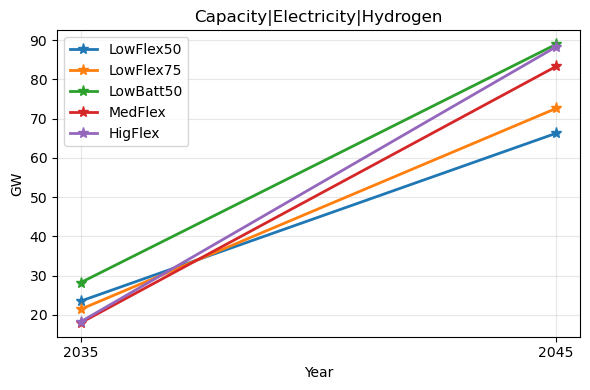

In [77]:
# plot_variable("Capacity|Electricity|Gas", results, scenarios)
plot_variable("Capacity|Electricity|Hydrogen", results, scenarios)

## Capacity Detailed

In [78]:
for year in [2045]:

    n = networks[("MedFlex", year)]

    capacities_electricity = (
        n.statistics.optimal_capacity(
            bus_carrier=["AC", "low voltage"],
            **kwargs,
        )
        .filter(like="DE")
        .groupby("carrier")
        .sum()
        .drop(
            # transmission capacities
            ["AC", "DC", "electricity distribution grid"],
            errors="ignore",
        )
    )

    print(year)
    print(capacities_electricity[capacities_electricity.index.str.contains('CCGT|OCGT|gas|H2 retrofit|H2 turbine|H2 CHP', case=False)] / 1e3)
    print()

2045
carrier
CCGT                         4.895490
H2 CCGT                      0.000905
H2 OCGT                     67.122416
H2 turbine                   0.079249
OCGT                         0.023310
urban central H2 CHP        16.215761
urban central gas CHP       12.241810
urban central gas CHP CC     0.000122
dtype: float64



## Export capacities csv

In [79]:
# f = "/home/julian-geis/repos/pypsa-de-flex/results/"
# run = "20251016-flex-more-scenarios" 
# scenarios = ["MediumFlex"]
# years = [2025, 2035, 2045]

# networks = {}
# for scenario in scenarios:
#     for year in years:
#         fn = f"{f}/{run}/{scenario}/networks/base_s_27__none_{year}.nc"
#         networks[(scenario, year)] = pypsa.Network(fn)
        
# kwargs = {
#     "groupby": ["name","bus", "carrier"],
#     "nice_names": False,
# }

# results_dict = {}

# for year in years:
#     n = networks[("MediumFlex", year)]
#     capacities = (
#         n.statistics.optimal_capacity(**kwargs)
#         .filter(like="DE")
#     )
#     results_dict[year] = capacities

# results = pd.concat(results_dict, axis=1)
# results.columns = years  # Clean up column names
# results.to_csv(f + run + "/MediumFlex_capacities_27cl_365H.csv")

# Secondary Energy / Generation

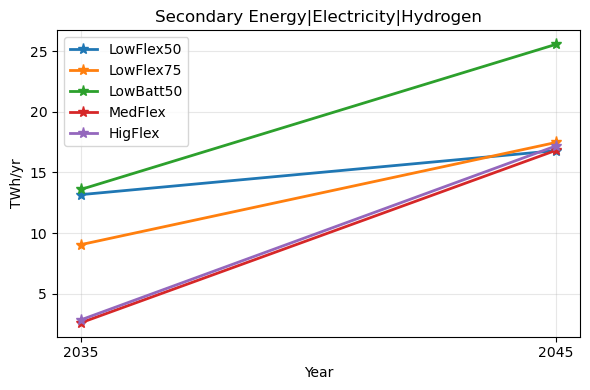

In [80]:
# plot_variable("Secondary Energy|Electricity|Gas", results, scenarios)
plot_variable("Secondary Energy|Electricity|Hydrogen", results, scenarios)

In [81]:
for year in [2045]:

    n = networks[("MedFlex", year)]

    generation_electricity = (
        n.statistics.supply(
            bus_carrier=["AC", "low voltage"],
            **kwargs,
        )
        .filter(like="DE")
        .groupby("carrier")
        .sum()
        .drop(
            # transmission capacities
            ["AC", "DC", "electricity distribution grid"],
            errors="ignore",
        )
    )

    print(year)
    print(generation_electricity[generation_electricity.index.str.contains('CCGT|OCGT|gas|H2 retrofit|H2 turbine|H2 CHP', case=False)] / 1e6)
    print() 

2045
carrier
CCGT                         4.957427
H2 CCGT                      0.000911
H2 OCGT                      6.494391
H2 turbine                   0.003381
OCGT                         0.009160
urban central H2 CHP        10.337110
urban central gas CHP        8.602210
urban central gas CHP CC     0.000184
dtype: float64



/home/julian-geis/repos/pypsa-de-flex/scripts/pypsa-de/flexibility_plots_scenario_comparison.py:929: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



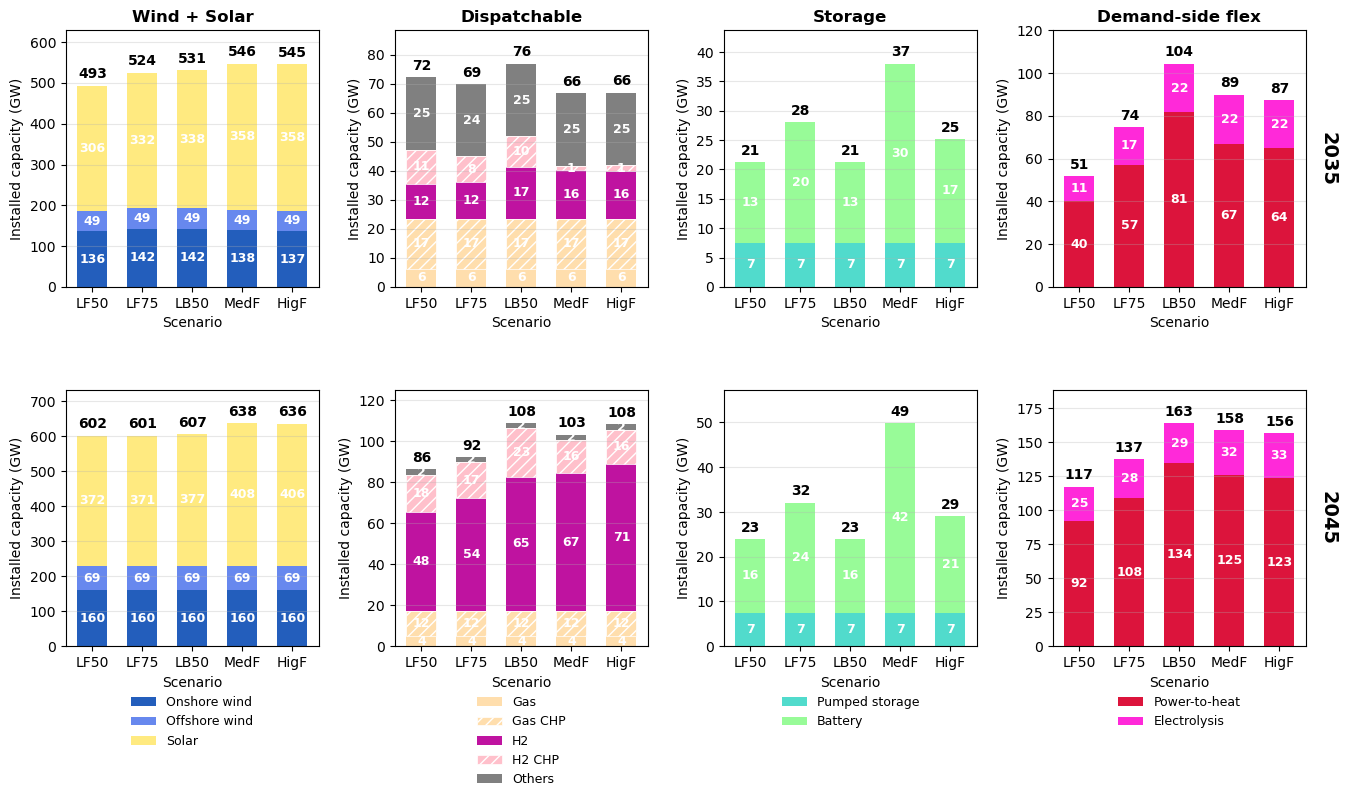

In [ ]:
# Convert networks from flat structure to nested structure to use repo function
# From: networks[(scenario, year)]
# To:   networks[scenario][year]

networks_nested = {}
for (scenario, year), network in networks.items():
    if scenario not in networks_nested:
        networks_nested[scenario] = {}
    networks_nested[scenario][year] = network

data = get_capacities(networks_nested, scenarios, [2035, 2045])
fig = plot_capacity_comparison(data, scenarios, [2035, 2045], tech_colors)

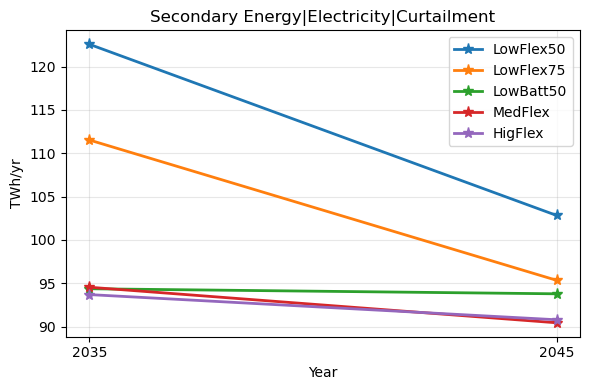

In [95]:
plot_variable("Secondary Energy|Electricity|Curtailment", results, scenarios)

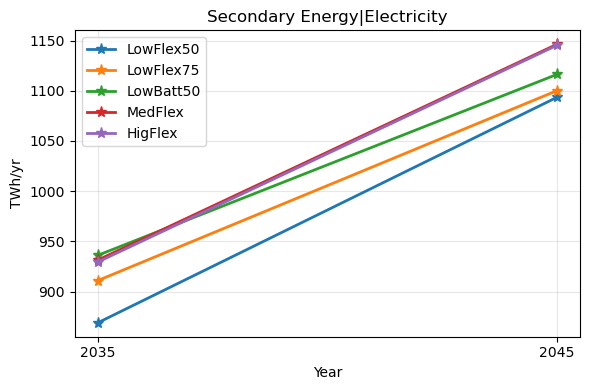

In [96]:
# Generation
plot_variable("Secondary Energy|Electricity", results, scenarios)
# plot_variable("Secondary Energy|Electricity|Biomass", results, scenarios)
# plot_variable("Secondary Energy|Electricity|Coal", results, scenarios)
# plot_variable("Secondary Energy|Electricity|Gas", results, scenarios)
# plot_variable("Secondary Energy|Electricity|Solar", results, scenarios)
# plot_variable("Secondary Energy|Electricity|Wind", results, scenarios)
# plot_variable("Secondary Energy|Electricity|Curtailment", results, scenarios)
# plot_variable("Secondary Energy|Electricity|Storage Losses", results, scenarios)
# plot_variable("Secondary Energy|Electricity|Hydrogen", results, scenarios)
# plot_variable("Secondary Energy|Electricity|Nuclear", results, scenarios)
# plot_variable("Secondary Energy|Electricity|Hydro", results, scenarios)
# plot_variable("Secondary Energy|Electricity|Waste", results, scenarios)
# plot_variable("Secondary Energy|Electricity|Fossil", results, scenarios)
# plot_variable("Secondary Energy|Electricity|Non-Biomass Renewables", results, scenarios)

In [97]:
## Trade

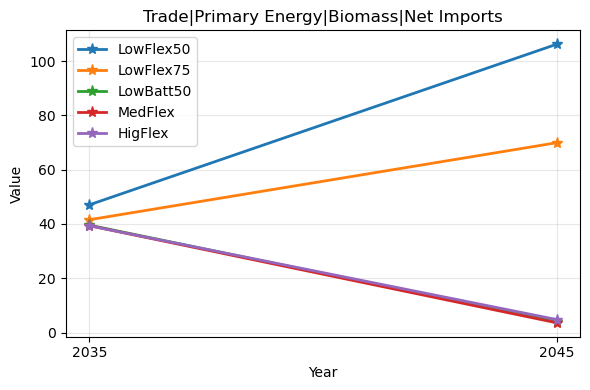

In [98]:
# Trade
plot_variable("Trade|Primary Energy|Biomass|Net Imports", results, scenarios)
# plot_variable("Trade|Secondary Energy|Electricity|Gross Import|Volume", results, scenarios)
# plot_variable("Trade|Secondary Energy|Electricity|Volume", results, scenarios)
# plot_variable("Trade|Secondary Energy|Electricity|Volume", results, scenarios)
# plot_variable("Trade|Secondary Energy|Hydrogen|Volume", results, scenarios)
# plot_variable("Trade|Secondary Energy|Hydrogen|Volume", results, scenarios)

In [ ]:
assert 0

# Testing

## Dispatchable

In [ ]:
n = networks[("MediumFlex", 2035)]

cf_electricity = (
    n.statistics.capacity_factor(
        bus_carrier=["AC", "low voltage"],
        **kwargs,
    )
    .filter(like="DE")
    .groupby("carrier")
    .sum()
)

cf_electricity[cf_electricity.index.str.contains('CCGT|OCGT|gas|H2 retrofit|H2 turbine|H2 CHP', case=False)]
cf = (generation_electricity / capacities_electricity /1e3)
cf[cf.index.str.contains('CCGT|OCGT|gas|H2 retrofit|H2 turbine|H2 CHP', case=False)]
disp_capa = capacities_electricity[capacities_electricity.index.str.contains('CCGT|OCGT|gas|H2 retrofit|H2 turbine|H2 CHP', case=False)] / 1e3
disp_gen = generation_electricity[generation_electricity.index.str.contains('CCGT|OCGT|gas|H2 retrofit|H2 turbine|H2 CHP', case=False)] / 1e6
disp_cf = disp_gen / (disp_capa * 2920) * 1e3
pd.concat([disp_capa, disp_gen, disp_cf], axis=1, keys=['Capacity [GW]', 'Generation [TWh]', 'Capacity Factor'])

# load pkl
import pickle

fn = "/home/julian-geis/Documents/06_PhD/02Flexibility/runs/20251015-flex-scenario-update-27cl-3h/MediumFlex/flexibility/data/flexibility_contributions_raw.pkl"
with open(fn, "rb") as f:
    flexibility_data = pickle.load(f)
    flexibility_data[2045].loc["weekly"].loc[["Supply_H2 OCGT" , "Supply_CCGT", "Supply_urban central H2 CHP", "Supply_urban central gas CHP"]]

    

## Percentage Scenarios

In [ ]:
capacities = pd.read_csv("/home/julian-geis/repos/pypsa-de-flex/flex-data/MediumFlex_capacities_27cl_3H.csv", index_col=[0, 1, 2])

In [ ]:
year = 2035
carrier = "H2 Electrolysis"
n = networks[("LowFlex50", year)]
n.links[(n.links.carrier == carrier) & (n.links.index.str.startswith("DE"))][["p_nom_opt", "p_nom_max"]]#.sum()

,p_nom_opt,p_nom_max
Link,,
DE0 0 H2 Electrolysis-2035,0.143709,0.147265
DE0 1 H2 Electrolysis-2035,3152.104972,3152.126895
DE0 2 H2 Electrolysis-2035,5962.814049,5962.863430
DE0 3 H2 Electrolysis-2035,2550.970955,2550.989065
DE0 4 H2 Electrolysis-2035,0.191514,0.194930
DE0 5 H2 Electrolysis-2035,0.099477,0.101125
DE0 6 H2 Electrolysis-2035,0.119176,0.121525
DE0 7 H2 Electrolysis-2035,0.146377,0.149270


In [ ]:
capacities["2035"].xs(carrier, level=2)

component  bus  
Link       DE0 0        0.29453
           DE0 1     6304.25379
           DE0 2    11925.72686
           DE0 3     5101.97813
           DE0 4        0.38986
           DE0 5        0.20225
           DE0 6        0.24305
           DE0 7        0.29854
Name: 2035, dtype: float64

In [ ]:
capacities["2045"].xs(carrier, level=2)

component  bus  
Link       DE0 0        0.00890
           DE0 1     6304.27616
           DE0 2    21698.76340
           DE0 3     5101.99563
           DE0 4        0.01105
           DE0 5        0.01115
           DE0 6        0.00808
           DE0 7        0.00731
Name: 2045, dtype: float64